This notebook shows you how to visualize the generator profiles provided by the NY Simple Net.

In [4]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cmaqpy.prepemis as emis

In [5]:
in_emis_file = '/home/jas983/models/ertac_egu/CONUS2016_S0/outputs/calc_hourly_base.csv'
co2_file = '../cmaqpy/data/ny_emis/ml_output/pred_xg_co2_fix.csv'
# co2_base_file = ''
nox_file = '../cmaqpy/data/ny_emis/ml_output/pred_xg_nox_fix.csv'
# nox_base_file = ''
so2_file = '../cmaqpy/data/ny_emis/ml_output/pred_xg_so2_fix.csv'
# so2_base_file = ''
gen_file = '../cmaqpy/data/ny_emis/ed_output/thermal_with_renewable_20160805_20160815.csv'
gen_base_file = '../cmaqpy/data/ny_emis/ed_output/thermal_without_renewable_20160805_20160815.csv'
lu_file = '../cmaqpy/data/ny_emis/ed_output/RGGI_to_NYISO.csv'

# Read in the base emissions file
base_df = emis.fmt_calc_hourly_base(base_file=in_emis_file)
# Read in ML CO2 emissions estimations
ml_co2 = emis.fmt_like_camd(data_file=co2_file, lu_file=lu_file)
# Read in ML NOx emissions estimations
ml_nox = emis.fmt_like_camd(data_file=nox_file, lu_file=lu_file)
# Read in ML SO2 emissions estimations
ml_so2 = emis.fmt_like_camd(data_file=so2_file, lu_file=lu_file)
# Read in NY Simple Net generation
ed_gen = emis.fmt_like_camd(data_file=gen_file, lu_file=lu_file)
ed_gen_base = emis.fmt_like_camd(data_file=gen_base_file, lu_file=lu_file)

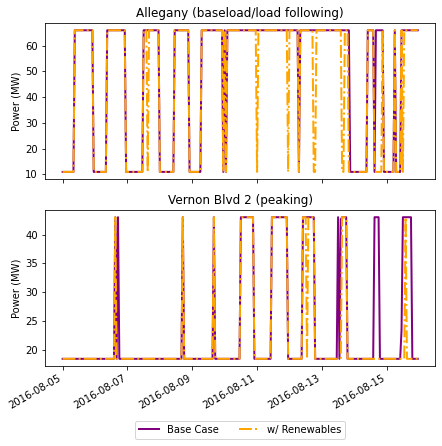

In [119]:
gen_idx1 = 2
gen_idx2 = 215

dis_change1 = pd.concat([ed_gen_base.iloc[gen_idx1,5:], ed_gen.iloc[gen_idx1,5:]], axis=1)
dis_change1.columns = ['Base Case', 'w/ Renewables']
dis_change2 = pd.concat([ed_gen_base.iloc[gen_idx2,5:], ed_gen.iloc[gen_idx2,5:]], axis=1)
dis_change2.columns = ['Base Case', 'w/ Renewables']
f, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(7,7))
# f = plt.figure(figsize=(7,3))
p1 = dis_change1.plot(color=['purple','orange'], linewidth=2, style=['-','-.'], ax=ax1)
p2 = dis_change2.plot(color=['purple','orange'], linewidth=2, style=['-','-.'], ax=ax2)
ax1.get_legend().remove()
ax2.legend(loc='lower center', bbox_to_anchor=(0.5, -0.5), ncol=2)
ax1.set_title(f'{ed_gen["NYISO Name"][gen_idx1]} (baseload/load following)')
ax2.set_title(f'{ed_gen["NYISO Name"][gen_idx2]} (peaking)')
ax1.set_ylabel('Power (MW)')
ax2.set_ylabel('Power (MW)')
plt.savefig(f'../cmaqpy/data/plots/gen_profs_{ed_gen["NYISO Name"][gen_idx1]}_{ed_gen["NYISO Name"][gen_idx2]}.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

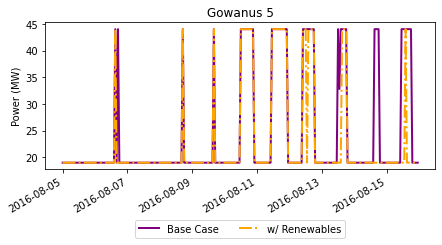

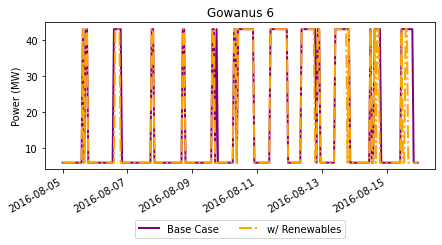

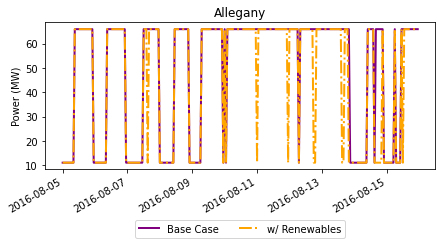

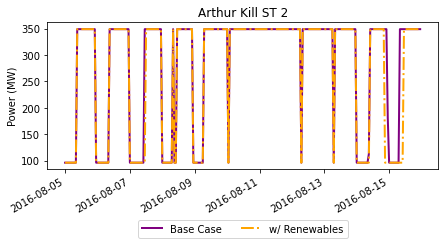

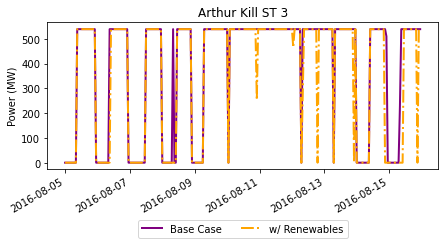

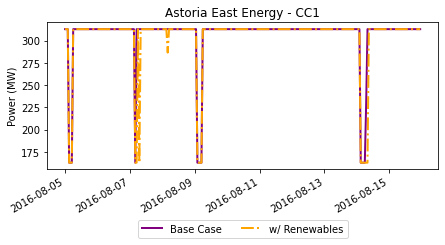

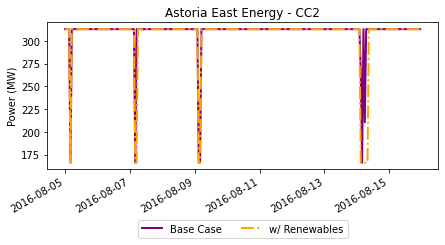

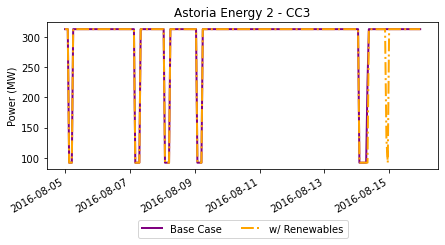

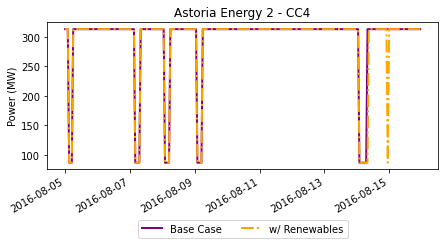

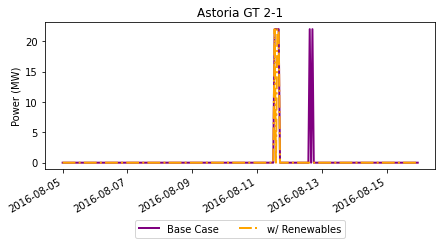

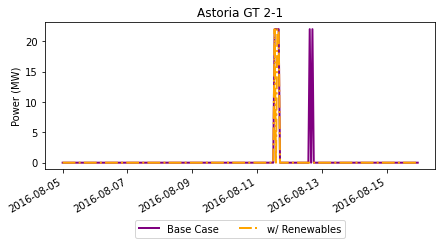

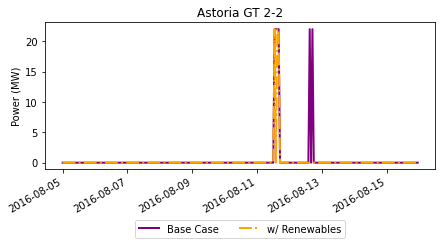

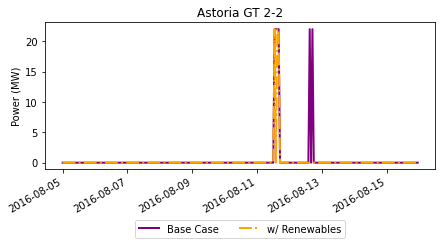

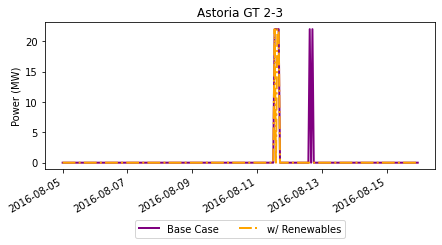

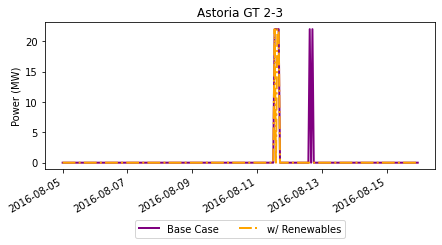

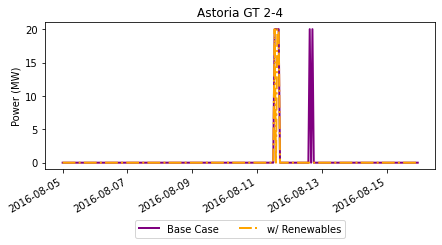

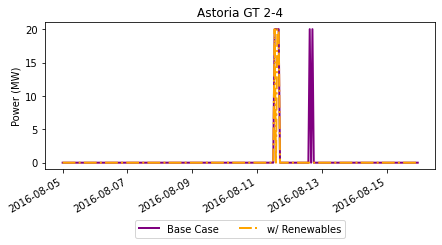

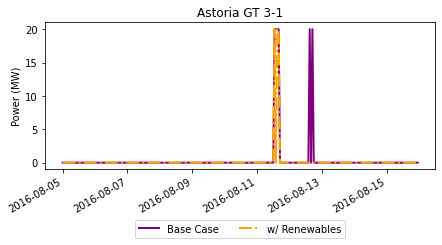

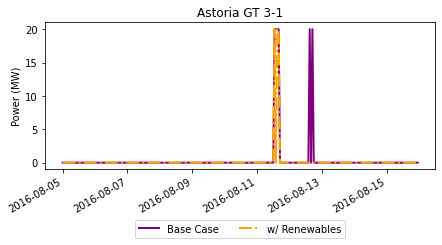

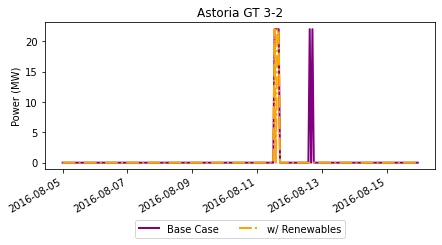

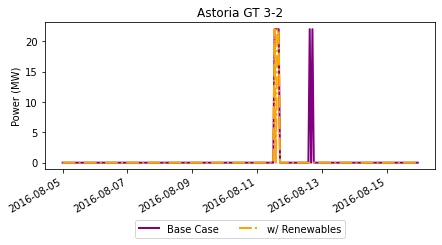

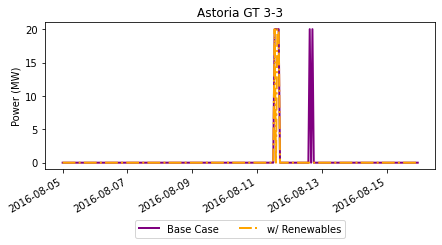

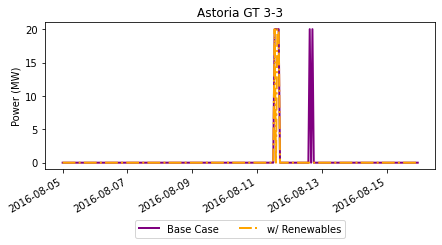

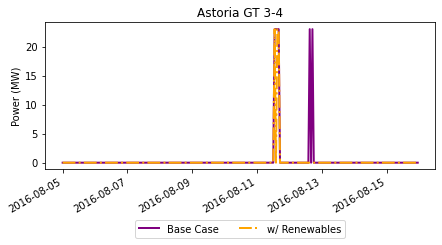

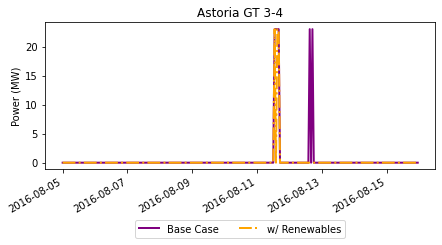

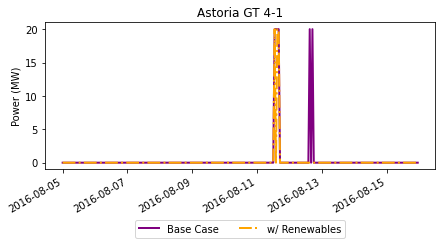

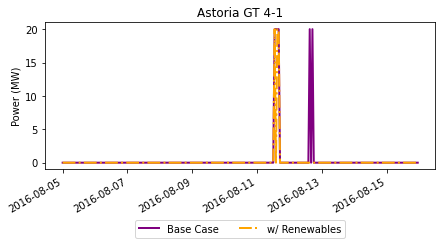

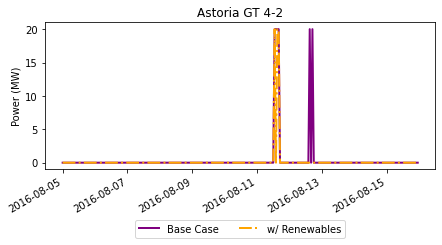

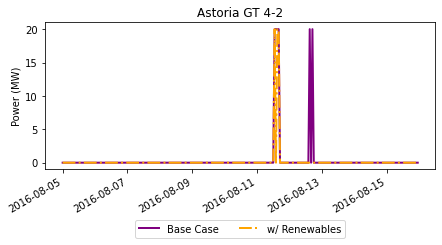

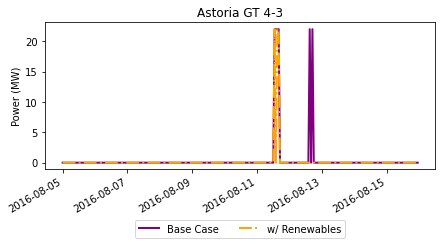

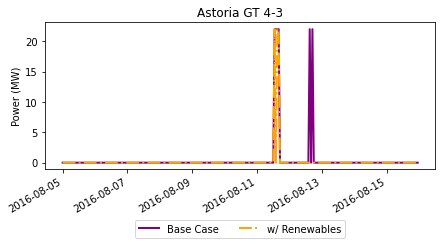

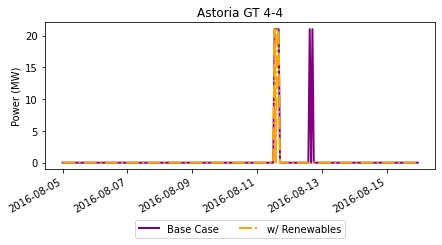

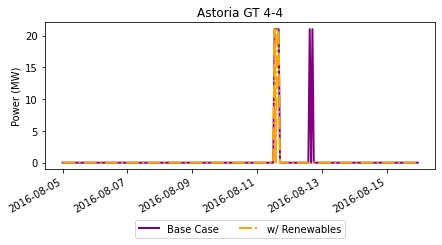

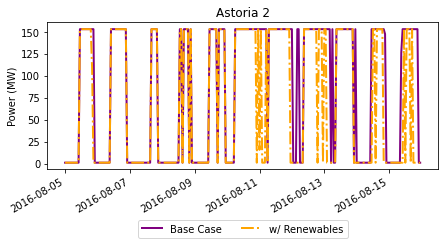

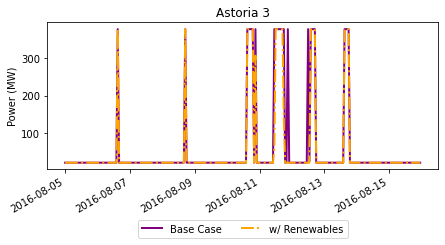

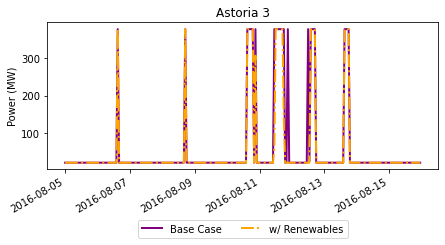

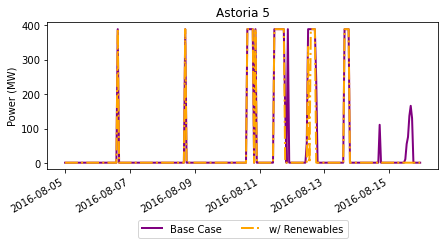

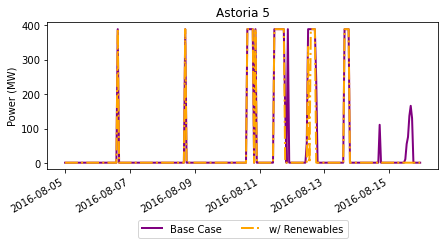

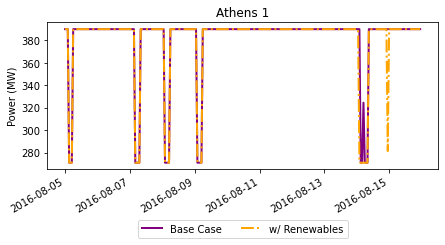

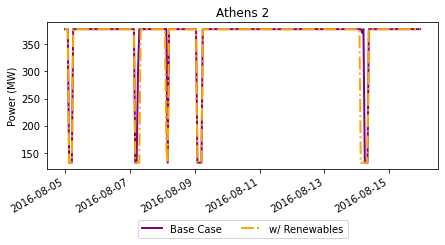

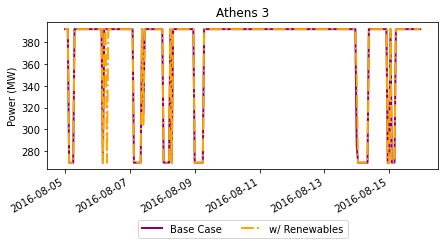

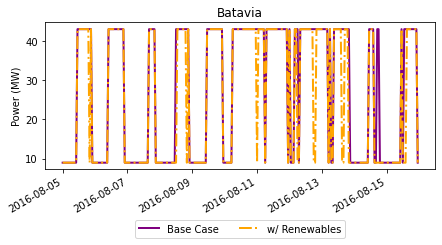

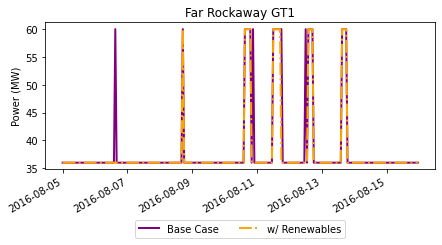

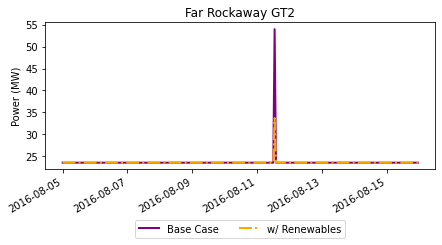

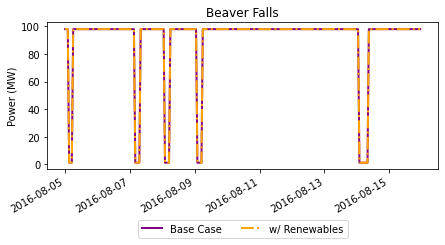

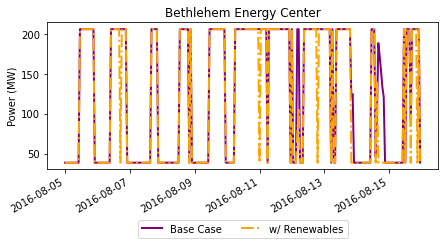

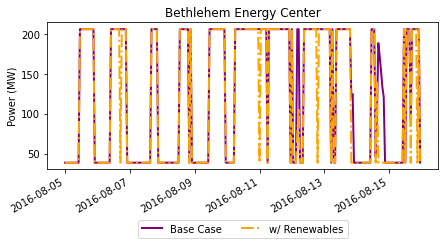

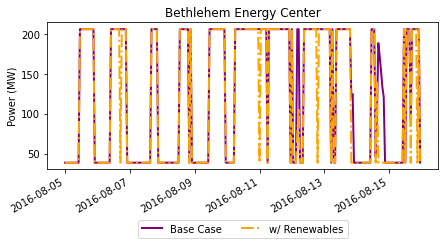

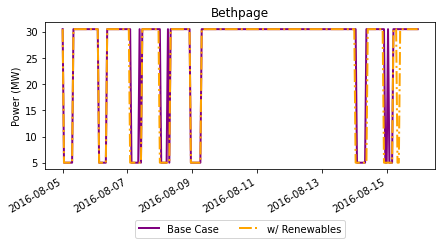

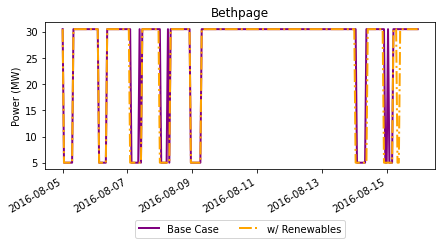

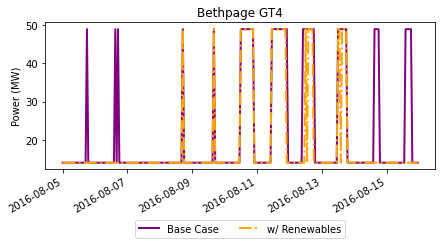

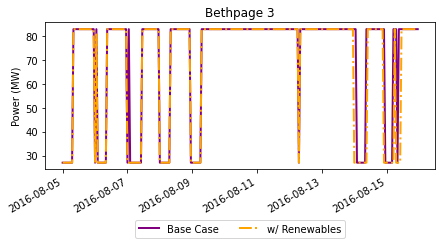

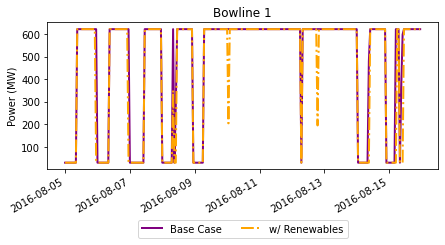

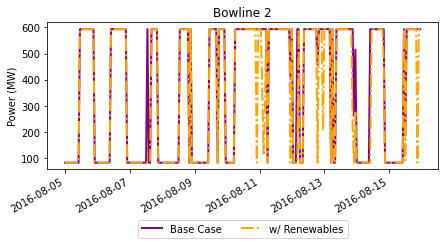

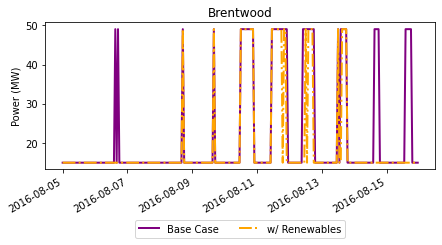

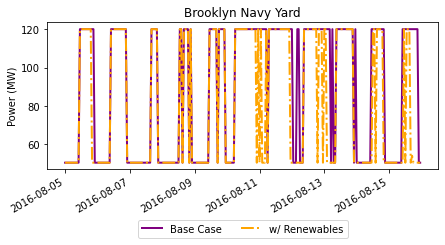

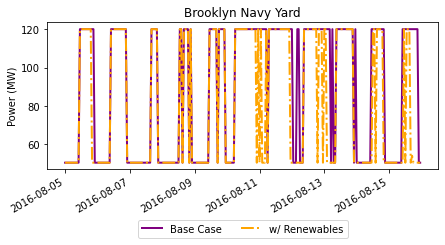

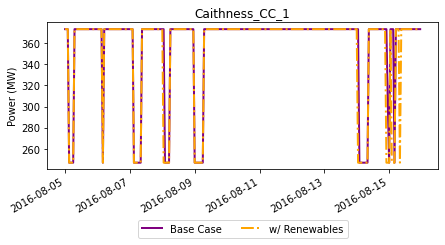

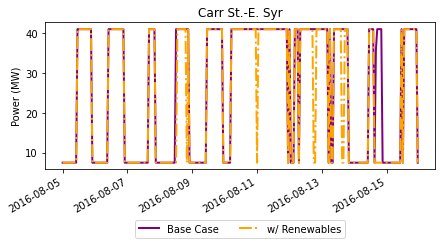

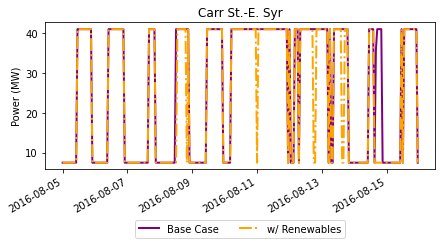

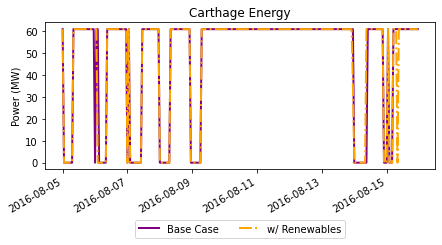

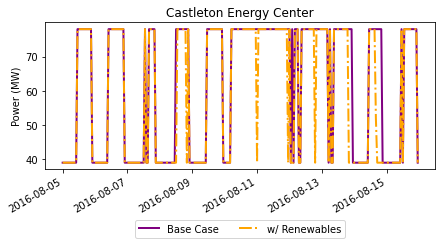

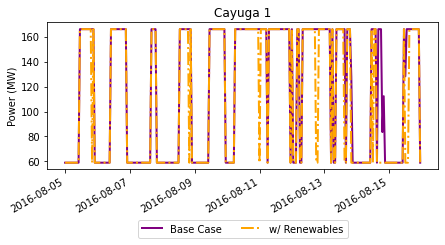

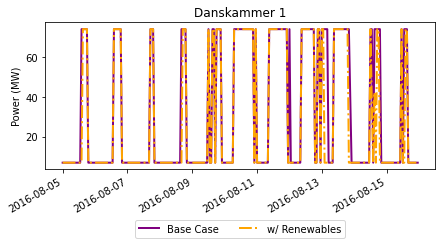

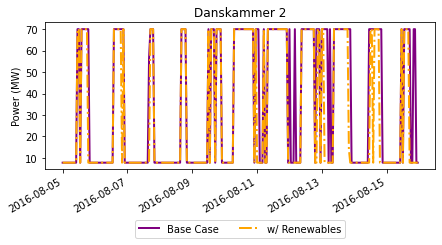

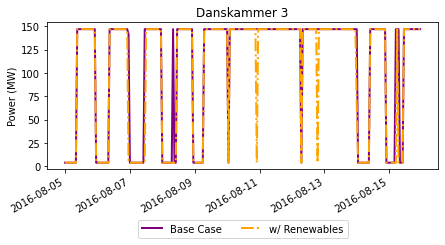

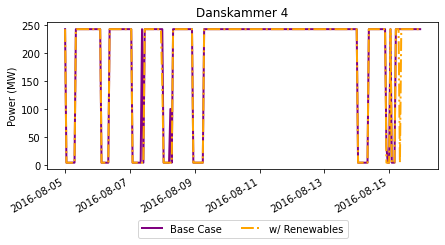

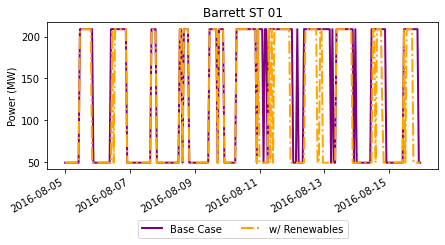

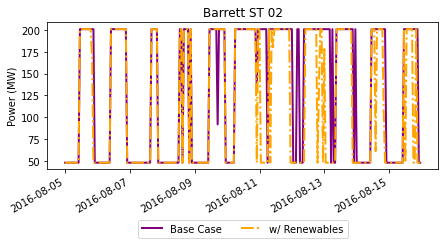

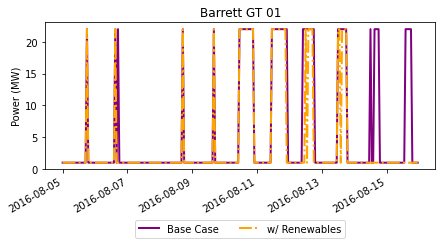

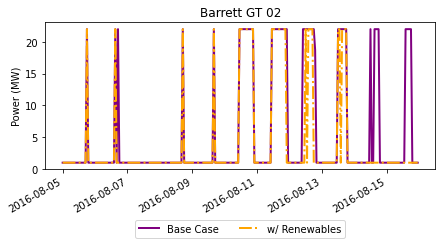

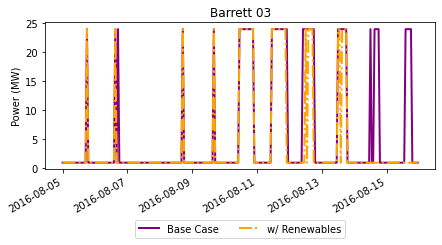

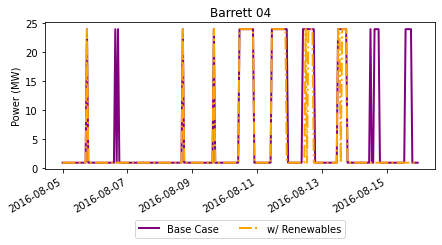

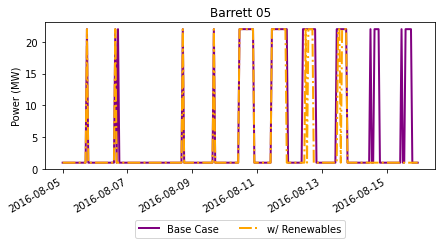

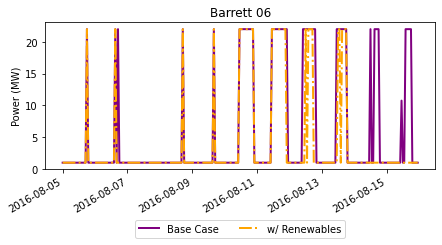

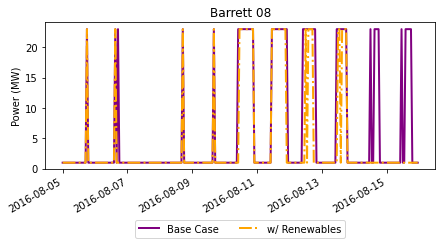

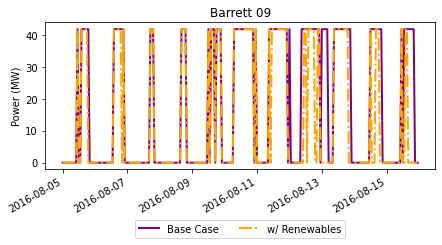

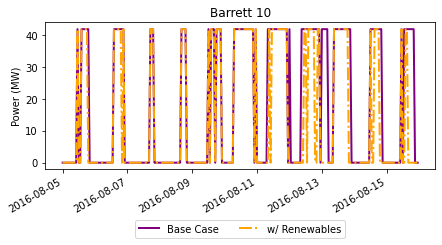

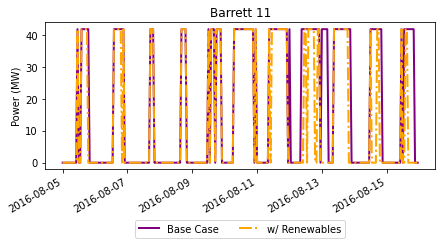

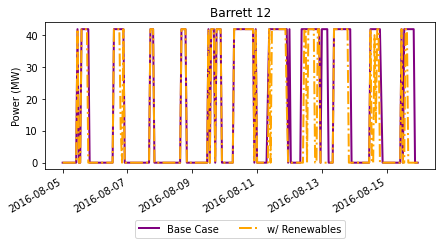

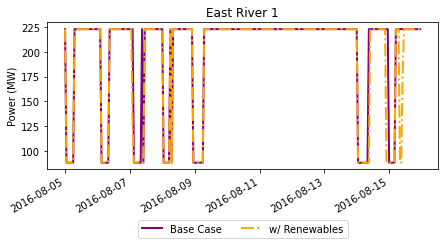

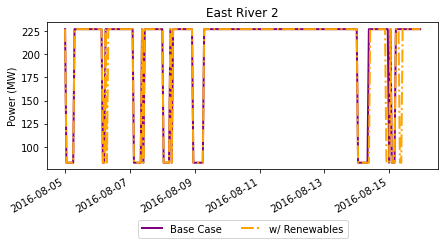

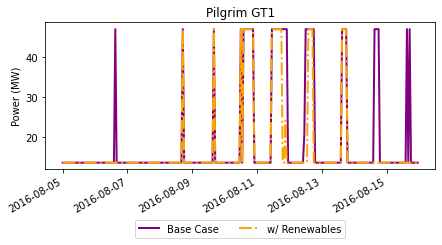

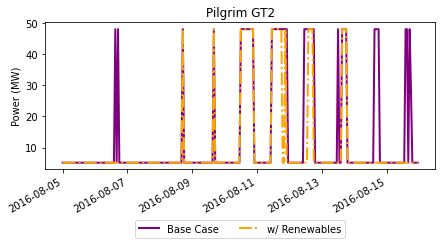

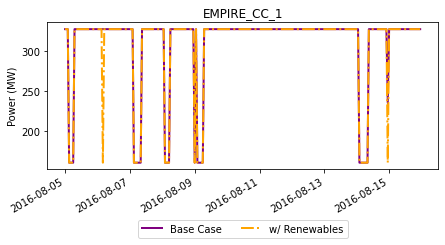

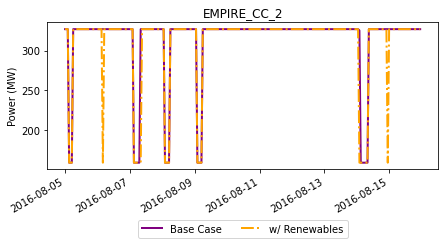

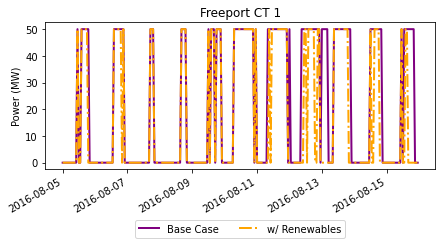

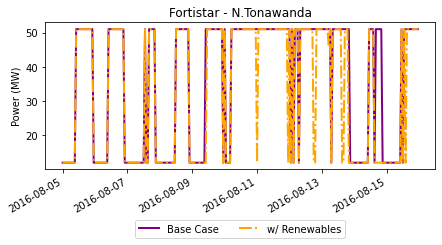

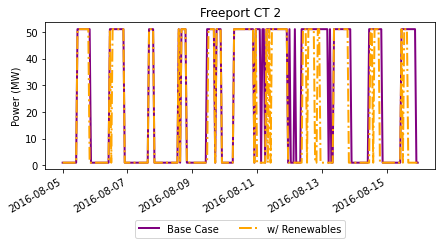

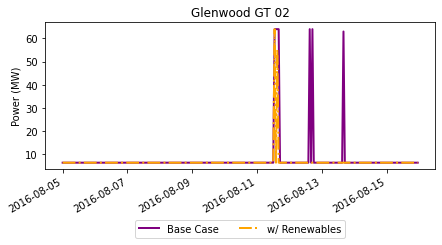

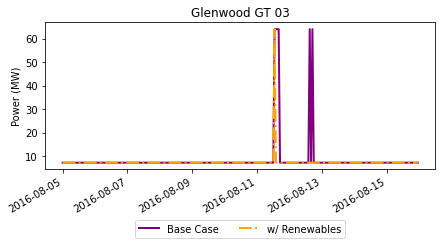

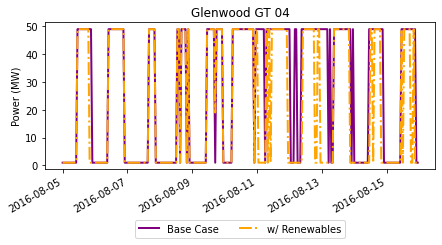

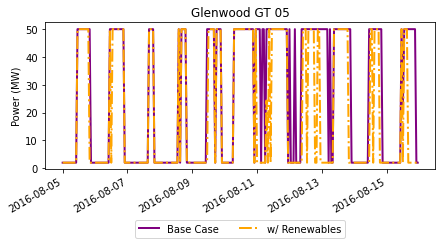

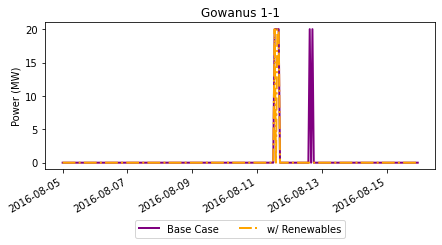

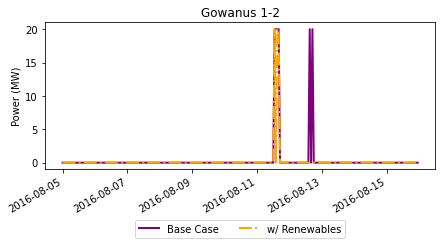

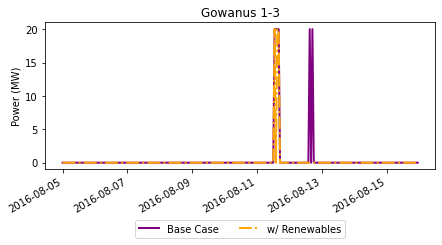

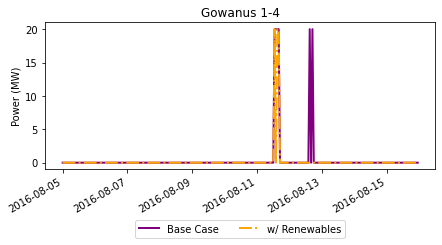

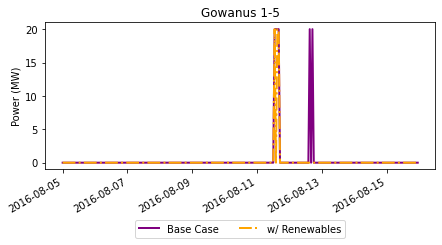

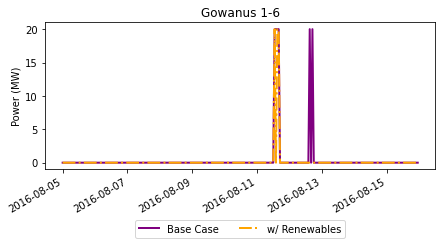

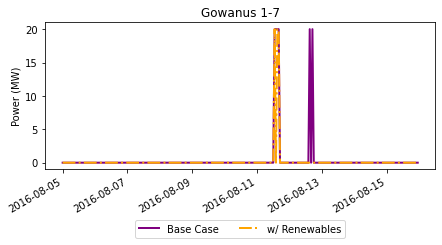

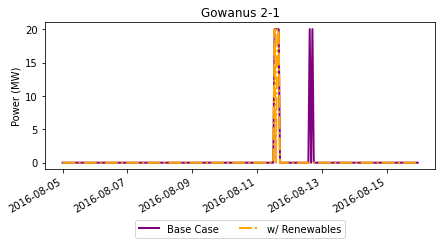

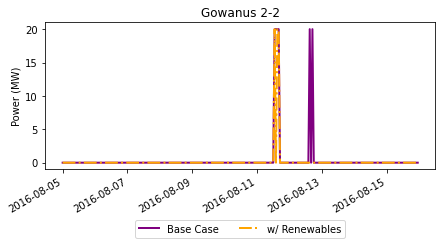

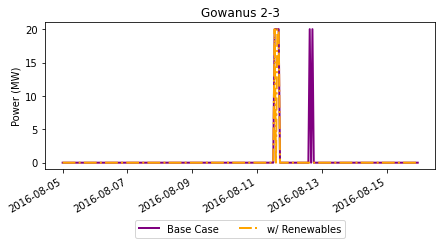

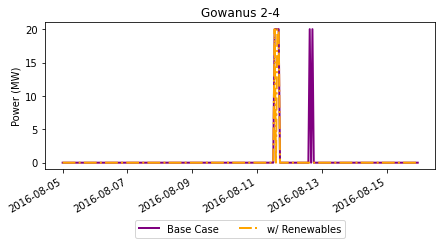

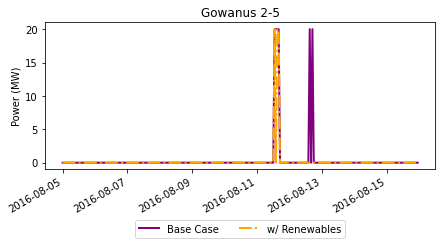

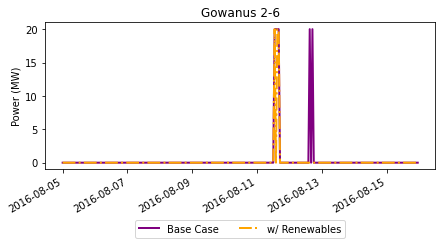

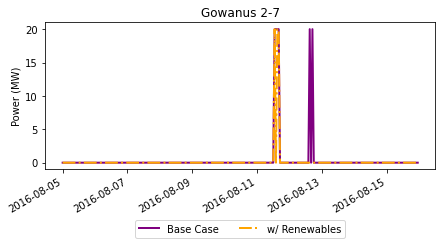

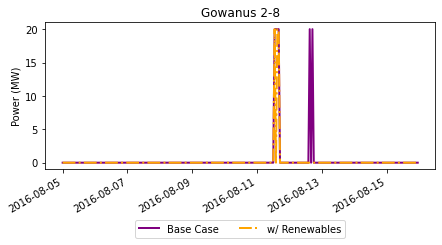

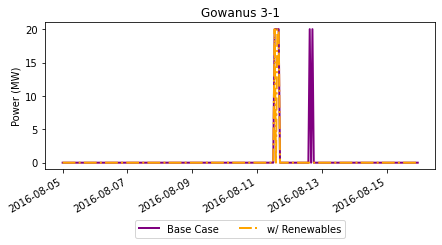

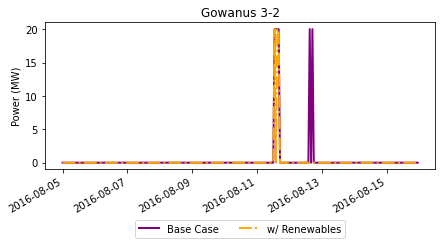

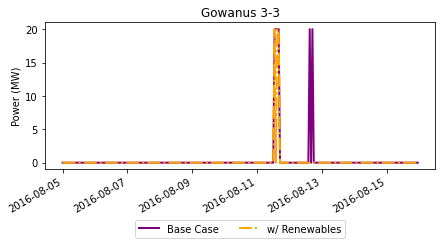

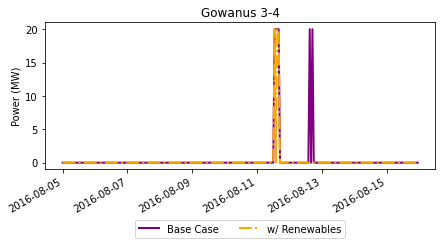

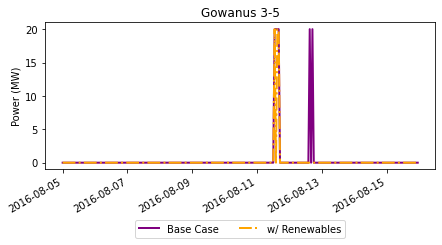

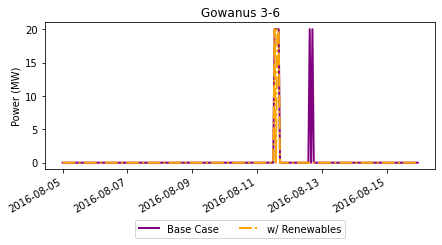

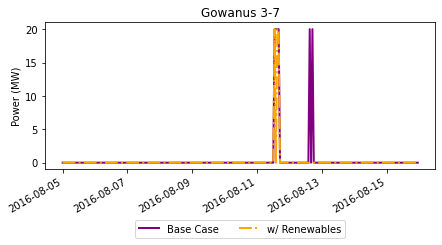

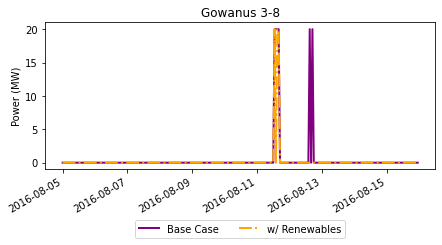

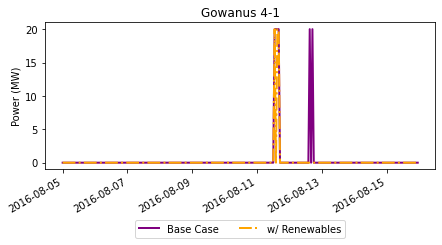

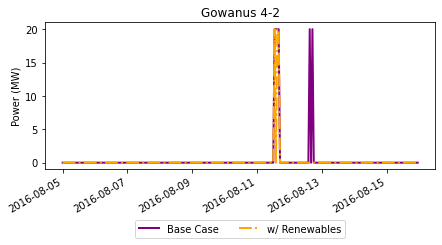

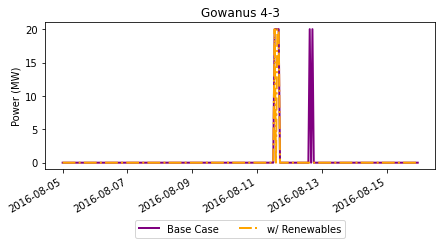

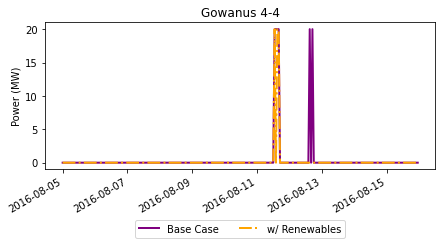

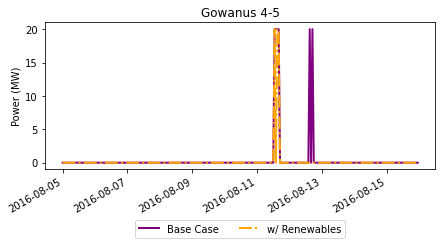

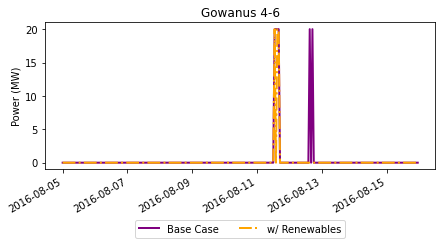

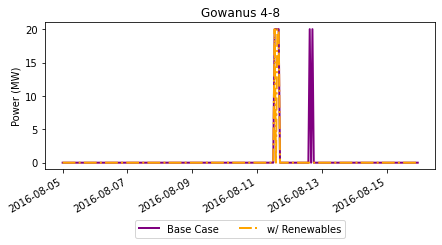

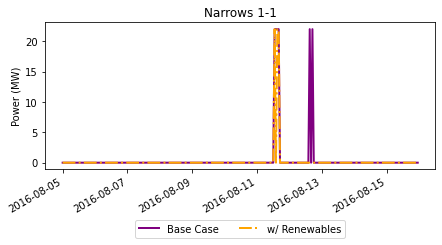

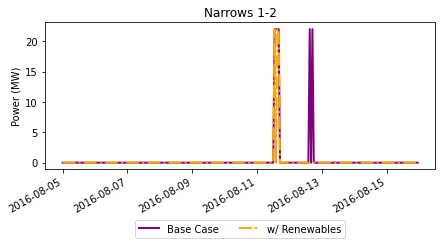

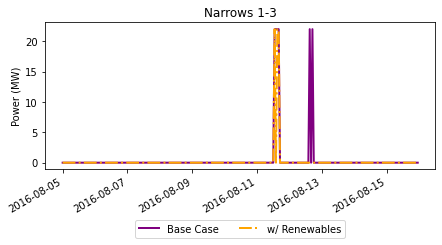

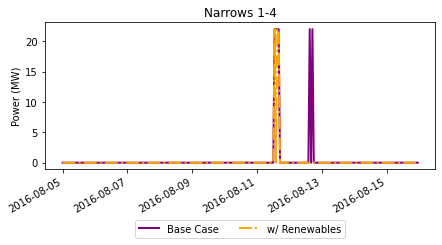

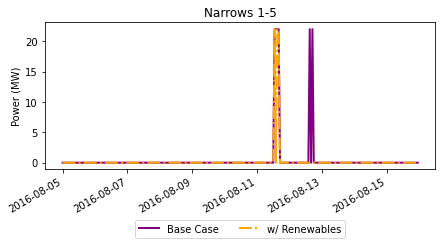

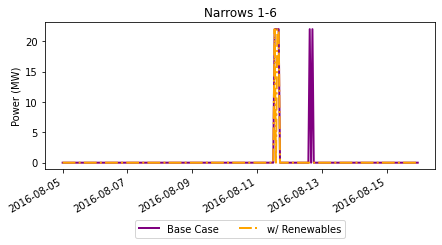

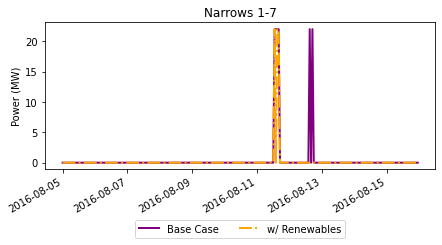

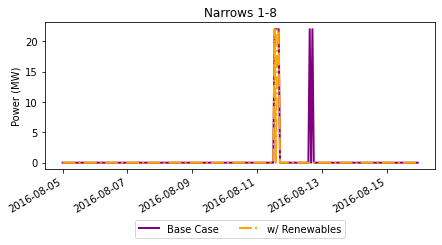

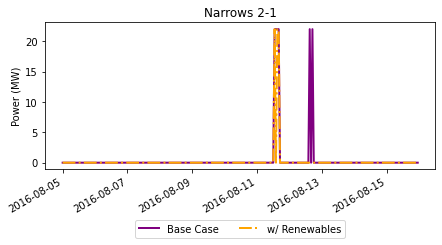

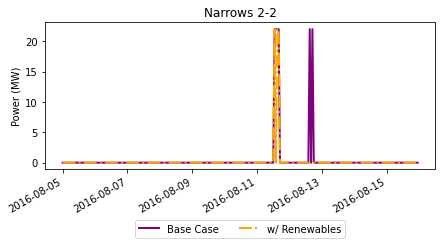

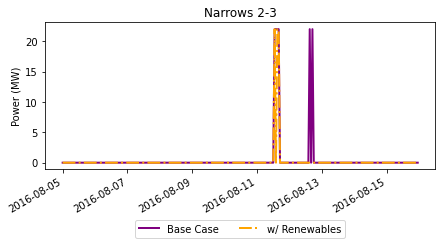

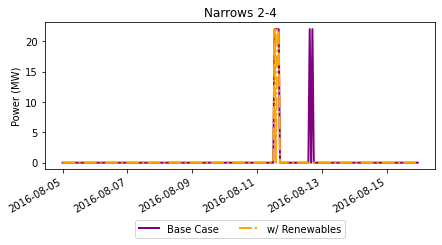

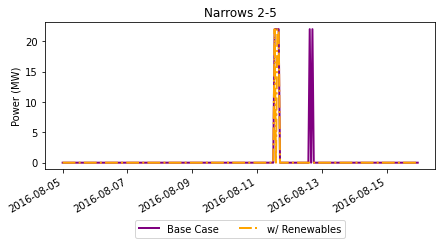

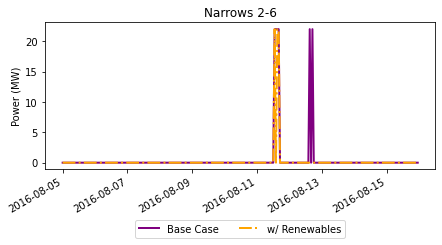

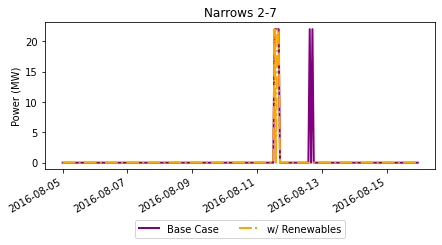

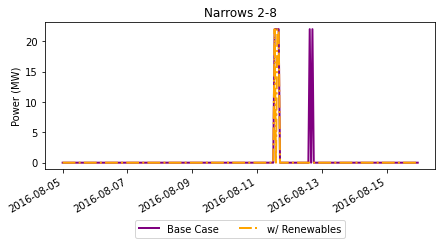

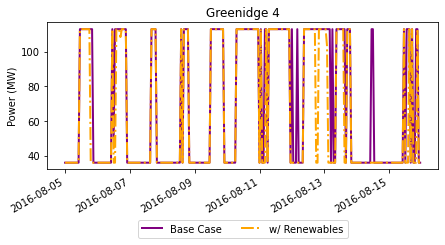

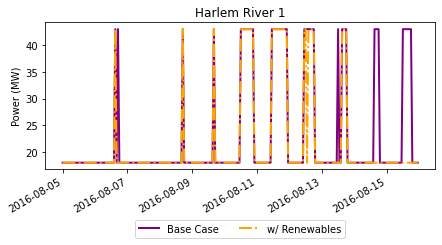

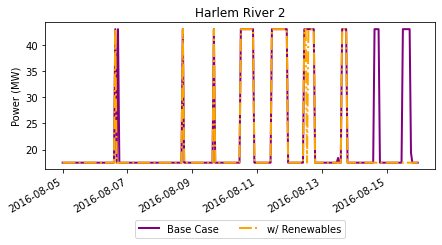

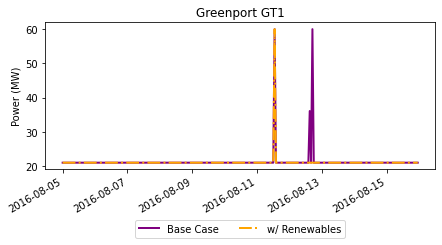

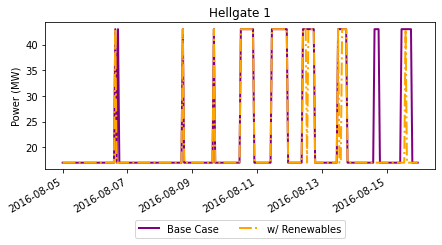

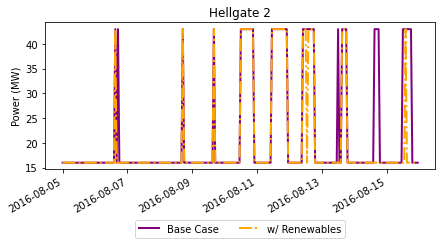

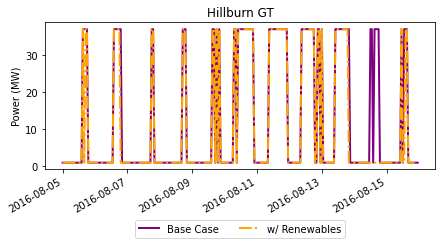

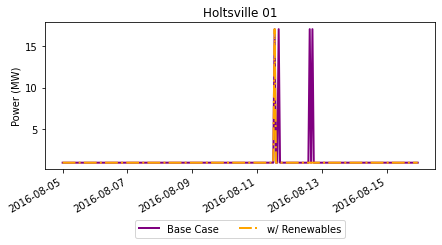

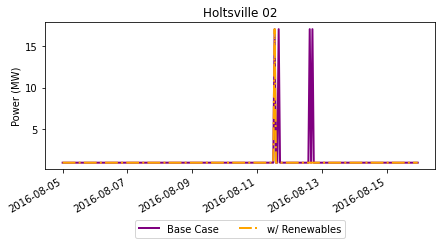

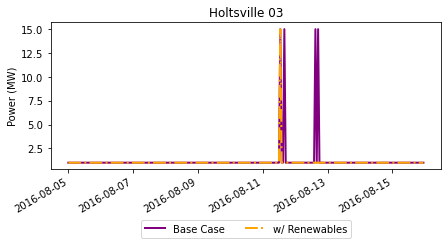

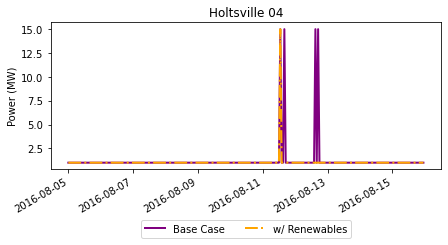

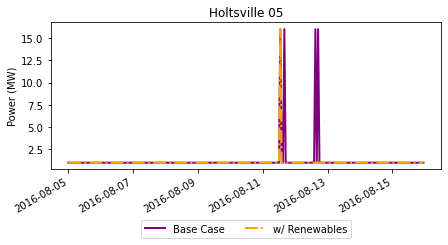

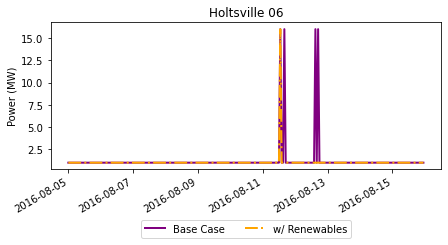

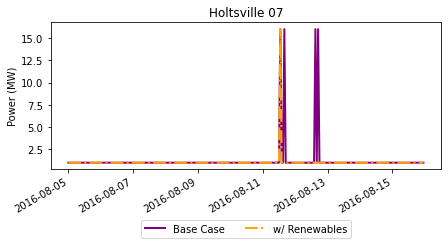

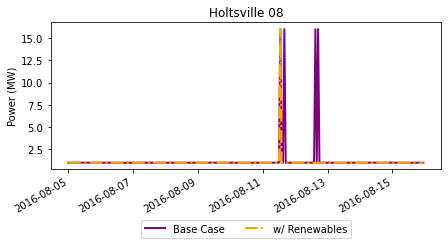

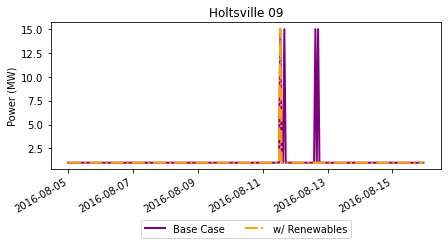

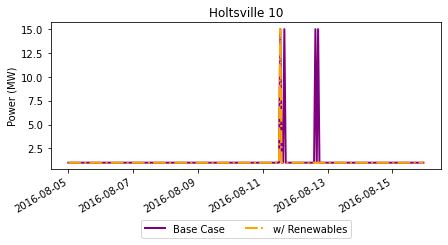

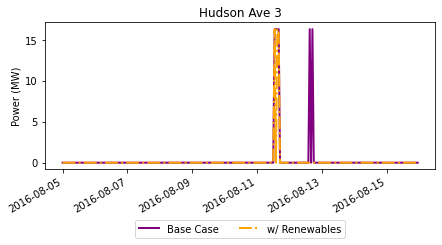

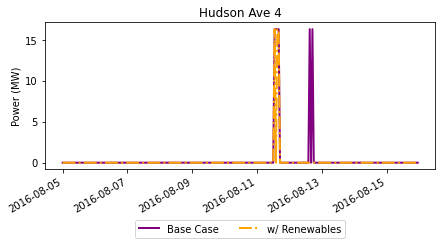

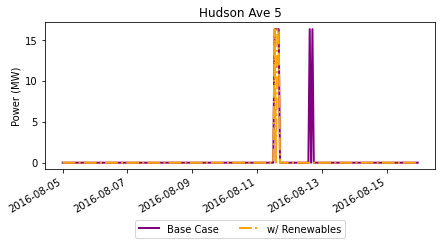

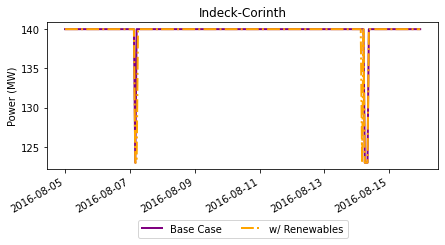

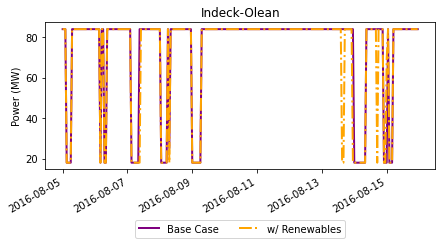

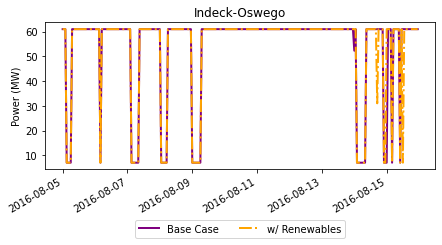

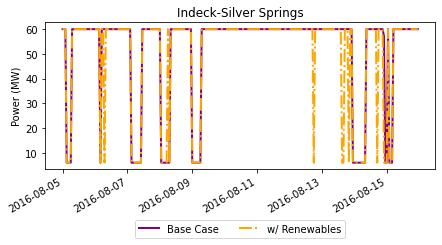

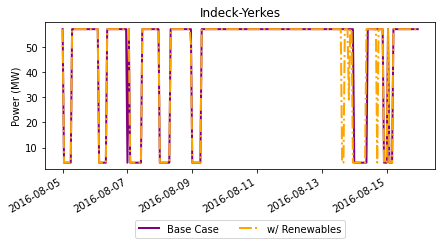

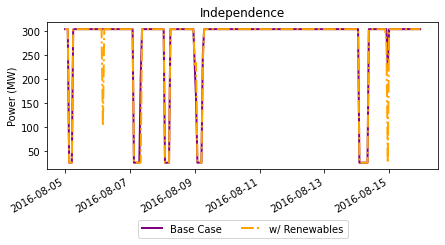

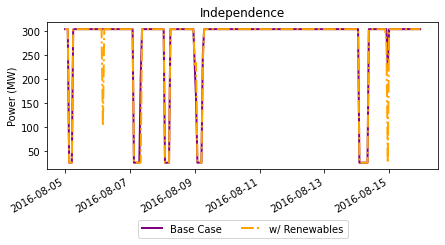

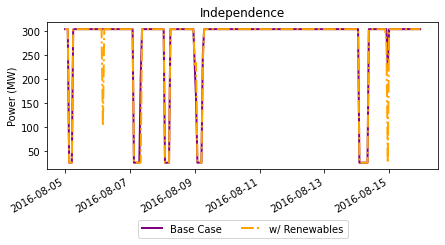

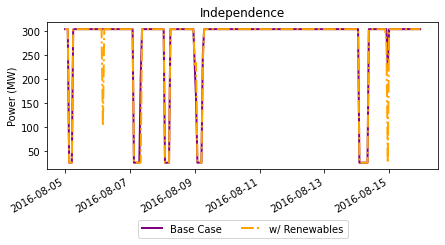

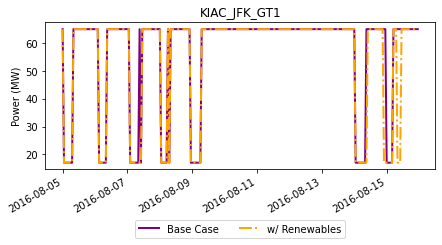

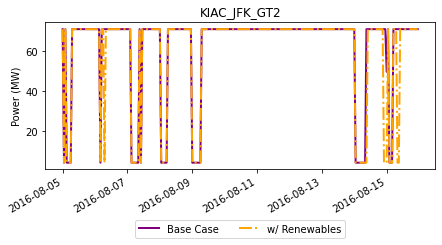

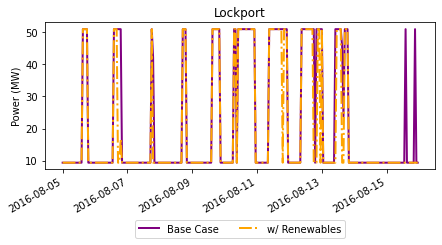

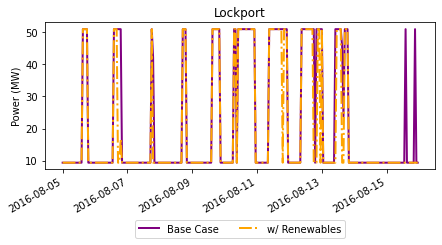

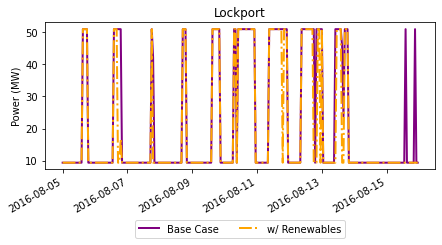

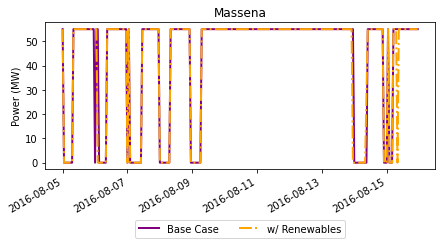

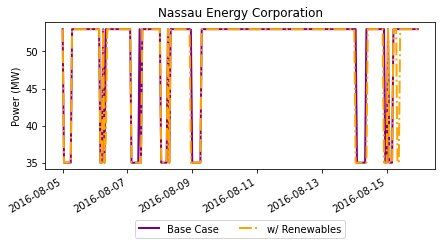

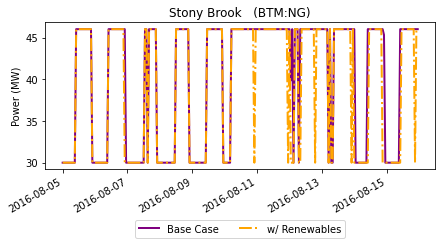

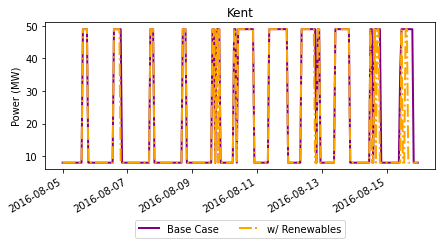

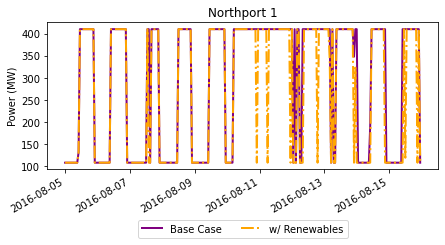

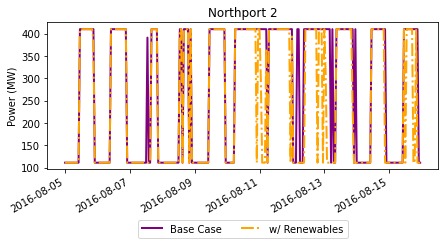

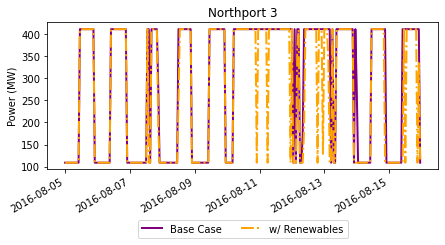

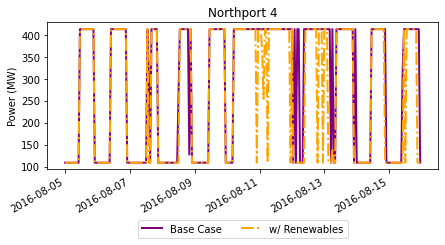

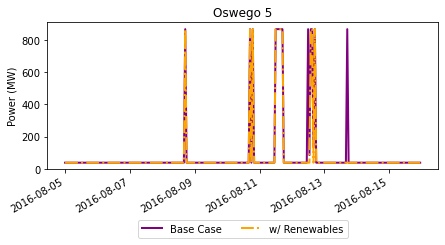

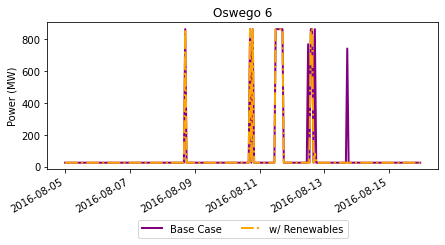

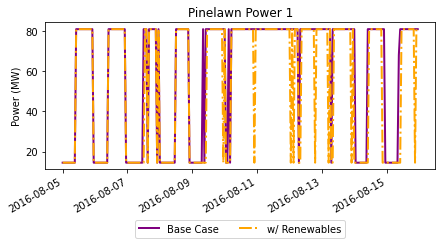

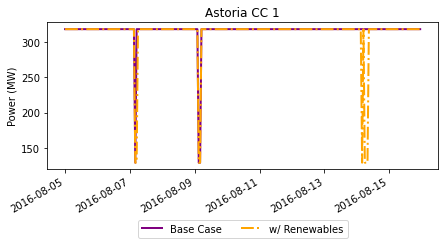

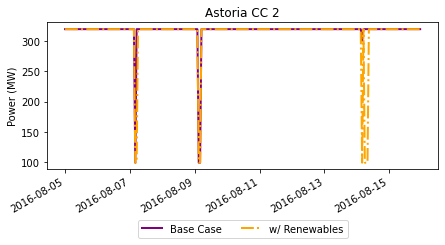

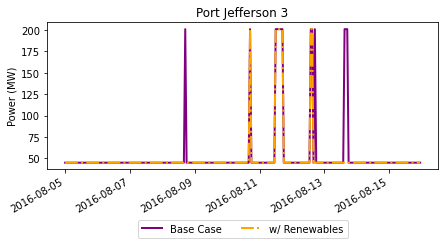

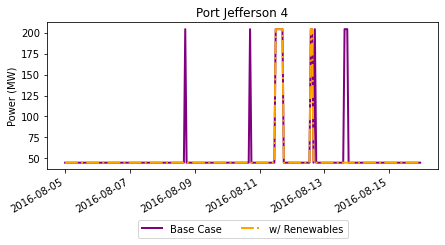

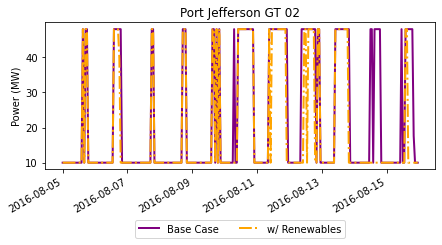

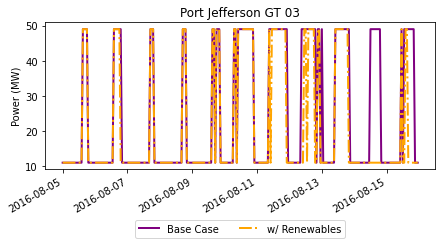

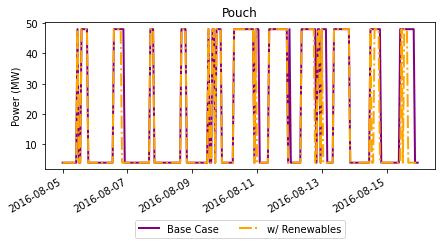

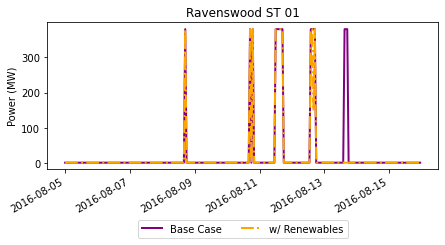

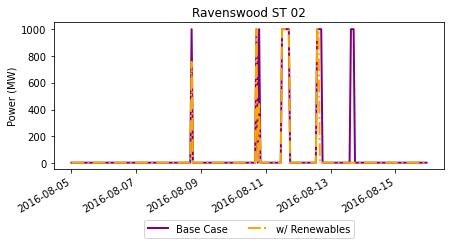

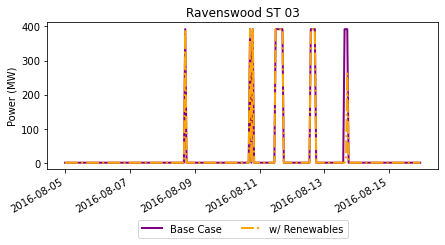

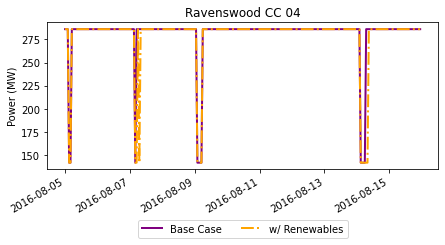

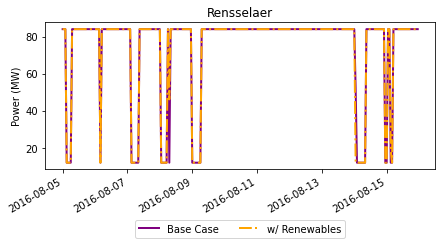

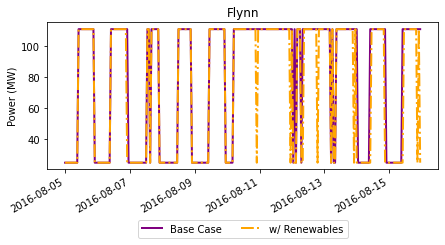

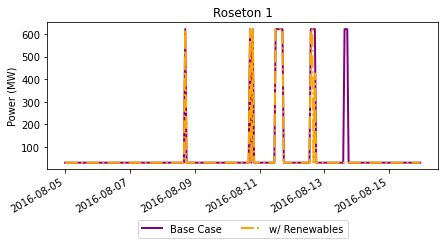

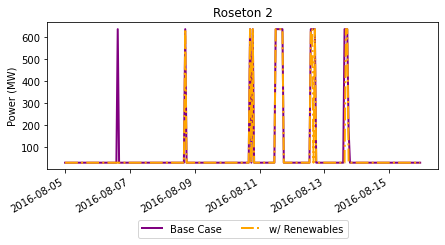

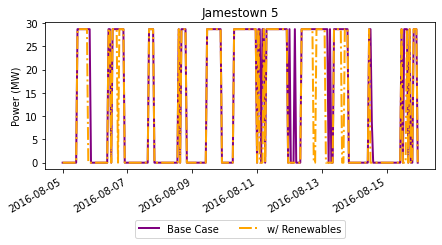

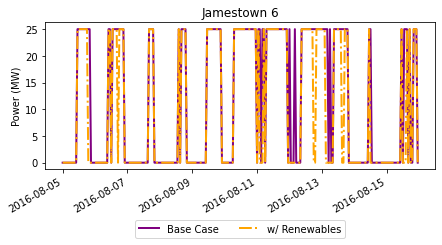

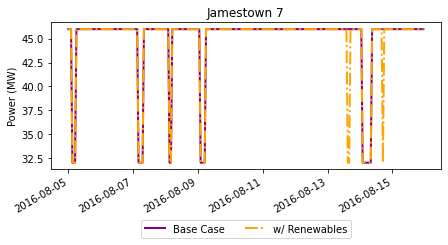

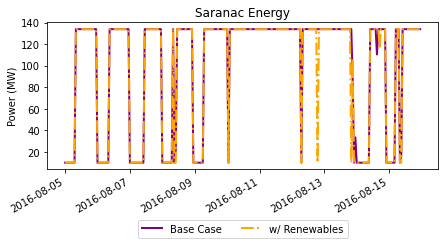

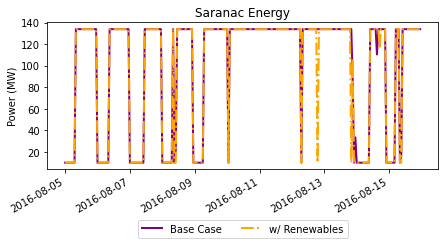

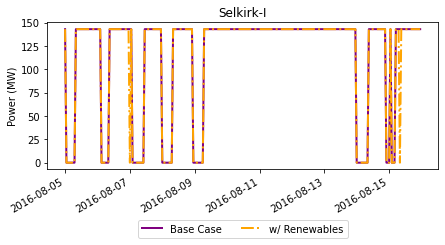

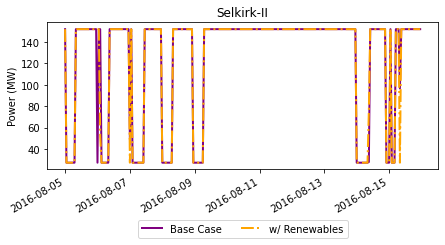

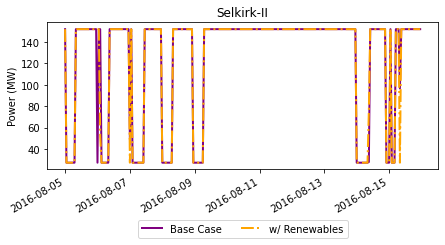

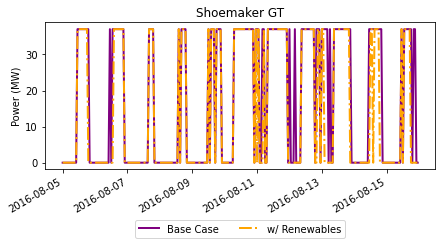

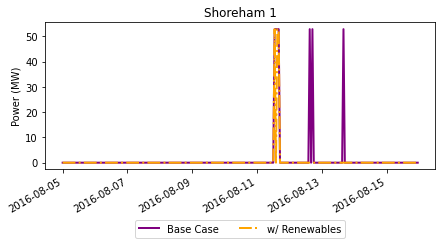

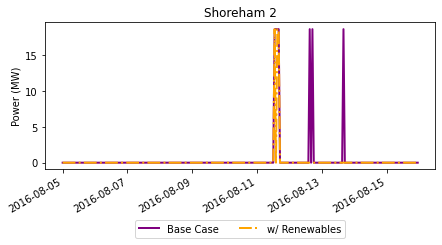

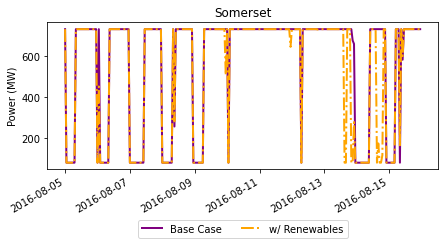

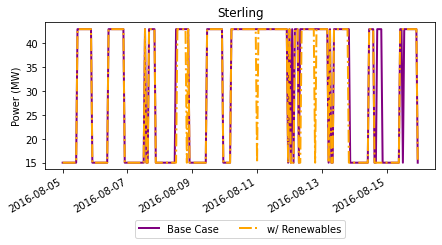

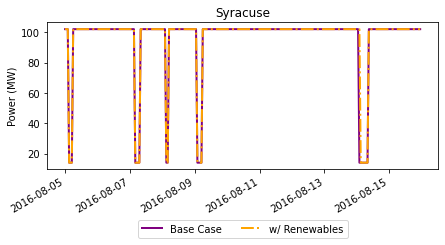

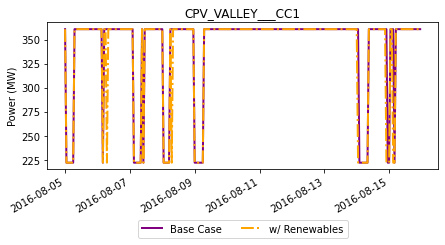

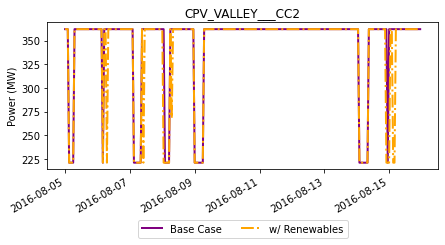

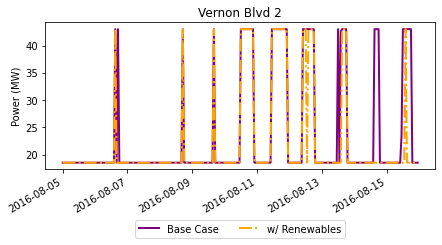

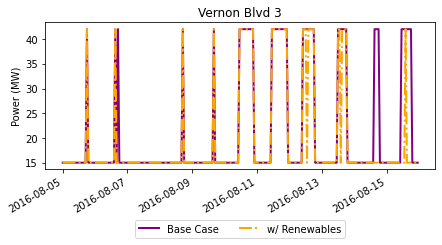

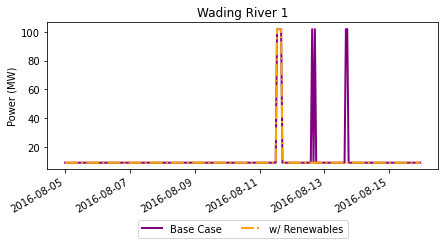

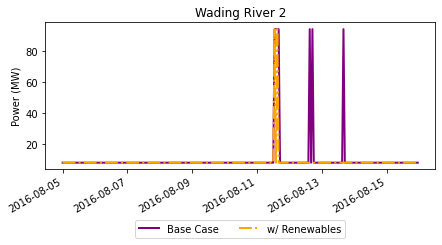

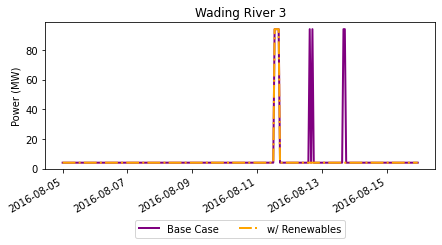

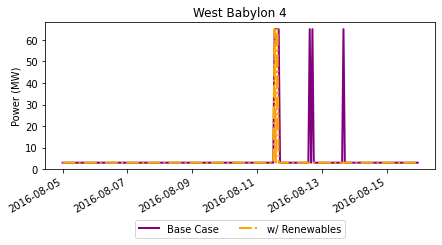

In [109]:
for gen_idx in ed_gen.index:
    dis_change = pd.concat([ed_gen_base.iloc[gen_idx,5:], ed_gen.iloc[gen_idx,5:]], axis=1)
    dis_change.columns = ['Base Case', 'w/ Renewables']
    f = plt.figure(figsize=(7,3))
    p = dis_change.plot(color=['purple','orange'], linewidth=2, style=['-','-.'], ax=f.gca())
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.5), ncol=2)
    plt.title(f'{ed_gen["NYISO Name"][gen_idx]}')
    plt.ylabel('Power (MW)')
    plt.show()